# Code for generation of coverage figures for the paper

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import glob
import os
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.transforms import offset_copy
plt.rcParams['font.family'] = 'Arial'

# Importing coverage data for plots

Coverage data was generated by RAVA pipeline.

In [37]:
files = glob.glob('../results/animal_results/genomecov/*.genomecov')

cov = None

for file_path in files:
    file_name = os.path.basename(file_path)
    sample_name = file_name.replace('.genomecov', '')

    df = pd.read_csv(file_path, sep='\t')

    if isinstance(df.index, pd.MultiIndex):
        df.index = df.index.droplevel(0)

    df.columns = [sample_name]

    if cov is None:
        cov = df
    else:
        cov = cov.join(df, how='outer')

sample_labels = {
  'kz_01_04b_4': 'Replicate 4',
  'kz_01_24a_1': 'Replicate 1',
  'kz_01_04b_5': 'Replicate 5',
  'kz_01_24a_2': 'Replicate 2',
  'kz_01_04b_6': 'Replicate 6',
  'kz_01_24a_3': 'Replicate 3',
  }
plot_col_headers = ['Ankle Tissue', 'Sorted Macrophages']
cov = cov.rename(columns=sample_labels)
cov = cov[sample_labels.values()]

# input coverage data import

inputs_files = glob.glob('../results/inoculum_results/input_genomcov/*.genomecov')

inputs_cov = None
for file_path in inputs_files:
    file_name = os.path.basename(file_path)
    sample_name = file_name.replace('.genomecov', '')

    df = pd.read_csv(file_path, sep='\t')

    if isinstance(df.index, pd.MultiIndex):
        df.index = df.index.droplevel(0)

    df.columns = [sample_name]

    if inputs_cov is None:
        inputs_cov = df
    else:
        inputs_cov = inputs_cov.join(df, how='outer')


input_sample_labels = {
  'kz_01_04b_input_1Msubsample': 'Ankle Tissue Input',
  'kz_01_24a_input_1Msubsample': 'Sorted Macrophages Input',
  }
inputs_cov = inputs_cov.rename(columns=input_sample_labels)
inputs_cov = inputs_cov[input_sample_labels.values()]


# Main text figures

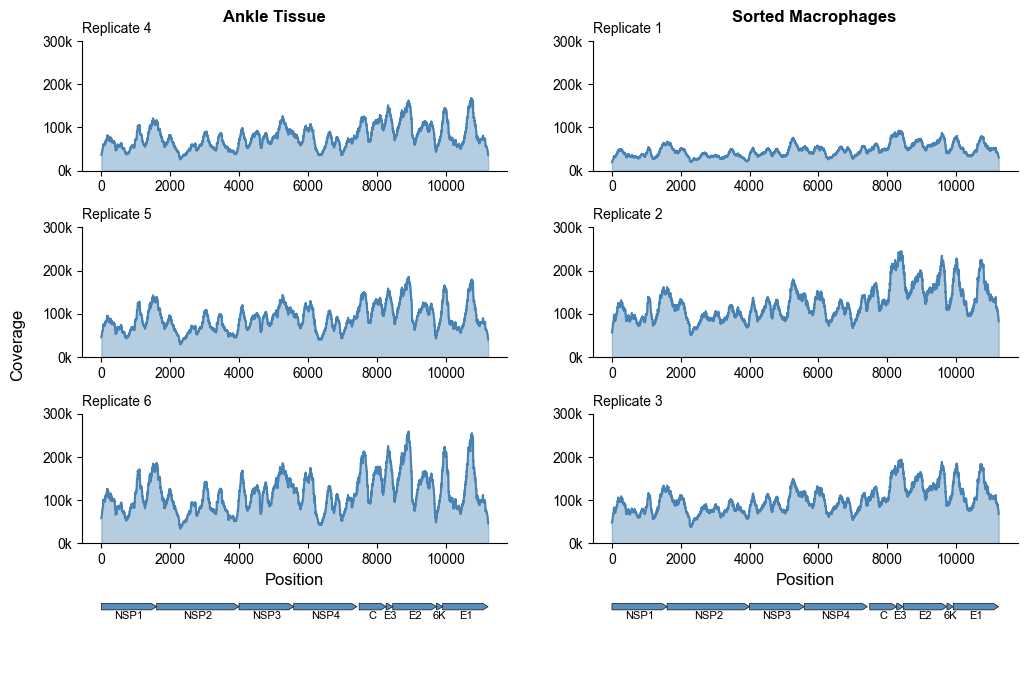

In [38]:
# Gene annotations
genes = [
  {"name": "NSP1", "start": 3, "end": 1605},
  {"name": "NSP2", "start": 1606, "end": 3999},
  {"name": "NSP3", "start": 4000, "end": 5589},
  {"name": "NSP4", "start": 5590, "end": 7425},
  {"name": "C", "start": 7491, "end": 8273},
  {"name": "E3", "start": 8274, "end": 8465},
  {"name": "E2", "start": 8466, "end": 9734},
  {"name": "6K", "start": 9735, "end": 9917},
  {"name": "E1", "start": 9918, "end": 11237},
]
single_color = 'steelblue'

sample_names = cov.columns
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(nrows=4, ncols=2, height_ratios=[0.6, 0.6, 0.6, 0.3], hspace=0.5)

axs = []
for i in range(6):
    row = i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    axs.append(ax)

for i, sample in enumerate(sample_names):
    ax = axs[i]
    ax.plot(cov.index, cov[sample], linestyle='-', color=single_color)
    ax.fill_between(cov.index, cov[sample], color=single_color, alpha=0.4)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
    ax.set_ylim(0, 300000)
    ax.set_title(sample, fontsize=10, loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axs[-2:]:
    ax.set_xlabel('Position', fontsize=12)

fig.text(0.06, 0.5, 'Coverage', va='center', rotation='vertical', fontsize=12)
fig.text(0.28, 0.90, plot_col_headers[0], ha='center', va='bottom', fontsize=12, weight='bold')
fig.text(0.73, 0.90, plot_col_headers[1], ha='center', va='bottom', fontsize=12, weight='bold')

for col in range(2):
    gene_ax = fig.add_subplot(gs[3, col])
    gene_ax.set_xlim(axs[0].get_xlim())
    gene_ax.set_ylim(0, 1)
    gene_ax.axis('off')

    arrow_y = 0.9

    for gene in genes:
        gene_start = gene['start']
        gene_end = gene['end']
        gene_width = gene_end - gene_start
        head_length = max(gene_width * 0.01, 150)

        arrow = patches.FancyArrow(
            gene_start, arrow_y,
            gene_width, 0,
            width=0.1,
            length_includes_head=True,
            head_width=0.1,
            head_length=head_length,
            facecolor=single_color,
            edgecolor='black',
            linewidth=0.5,
            alpha=0.9
        )
        gene_ax.add_patch(arrow)

        gene_ax.text(
            (gene_start + gene_end) / 2,
            arrow_y - 0.07,
            gene['name'],
            ha='center',
            va='top',
            fontsize=8,
            color='black'
        )

fig.subplots_adjust(left=0.12, bottom=0.1)
fig.savefig('./figures/ankle_macrophages_genomecov.pdf', bbox_inches='tight')
plt.show()


# Supplementary figures

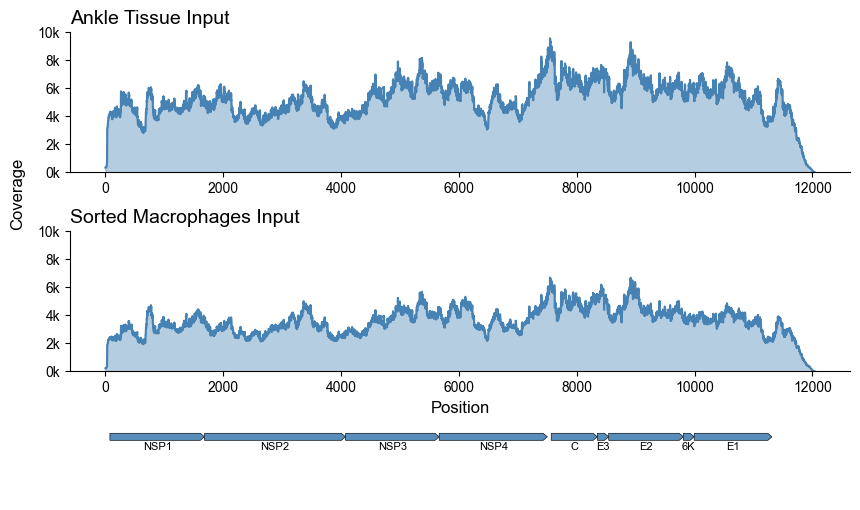

In [39]:
# Gene annotations
inputs_genes = [
  {"name": "NSP1", "start": 77, "end": 1681},
  {"name": "NSP2", "start": 1682, "end": 4075},
  {"name": "NSP3", "start": 4076, "end": 5665},
  {"name": "NSP4", "start": 5666, "end": 7501},
  {"name": "C", "start": 7567, "end": 8349},
  {"name": "E3", "start": 8350, "end": 8541},
  {"name": "E2", "start": 8542, "end": 9810},
  {"name": "6K", "start": 9811, "end": 9993},
  {"name": "E1", "start": 9994, "end": 11313},
]

input_sample_names = inputs_cov.columns
fig_inputs = plt.figure(figsize=(10, 6))
gs_inputs = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.6, 0.6, 0.3], hspace=0.5)

axs_inputs = []
for i in range(2):
    ax = fig_inputs.add_subplot(gs_inputs[i, 0])
    axs_inputs.append(ax)

for i, sample in enumerate(input_sample_names):
    ax = axs_inputs[i]
    ax.plot(inputs_cov.index, inputs_cov[sample], linestyle='-', color=single_color)
    ax.fill_between(inputs_cov.index, inputs_cov[sample], color=single_color, alpha=0.4)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
    ax.set_ylim(0, 10000)
    ax.set_title(sample, fontsize=14, loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs_inputs[-1].set_xlabel('Position', fontsize=12)

fig_inputs.text(0.06, 0.61, 'Coverage', va='center', rotation='vertical', fontsize=12)

gene_ax = fig_inputs.add_subplot(gs_inputs[2, 0])
gene_ax.set_xlim(cov.index.min(), cov.index.max())
gene_ax.set_xlim(axs_inputs[0].get_xlim())
gene_ax.set_ylim(0, 1)
gene_ax.axis('off')

arrow_y = 0.9 

for gene in inputs_genes:
    gene_start = gene['start']
    gene_end = gene['end']
    gene_width = gene_end - gene_start
    head_length = max(gene_width * 0.01, 70)

    arrow = patches.FancyArrow(
        gene_start, arrow_y,
        gene_width, 0,
        width=0.1,
        length_includes_head=True,
        head_width=0.1,
        head_length=head_length,
        facecolor=single_color,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.9
    )
    gene_ax.add_patch(arrow)

    gene_ax.text(
        (gene_start + gene_end) / 2,
        arrow_y - 0.07,
        gene['name'],
        ha='center',
        va='top',
        fontsize=8,
        color='black'
    )

fig_inputs.subplots_adjust(left=0.12, bottom=0.1)
fig_inputs.savefig('./figures/inputs_genomecov.pdf', bbox_inches='tight')
plt.show()


Animal derived samples coverage with added markers for SNVs with AF >= 10% detected in the respective samples.

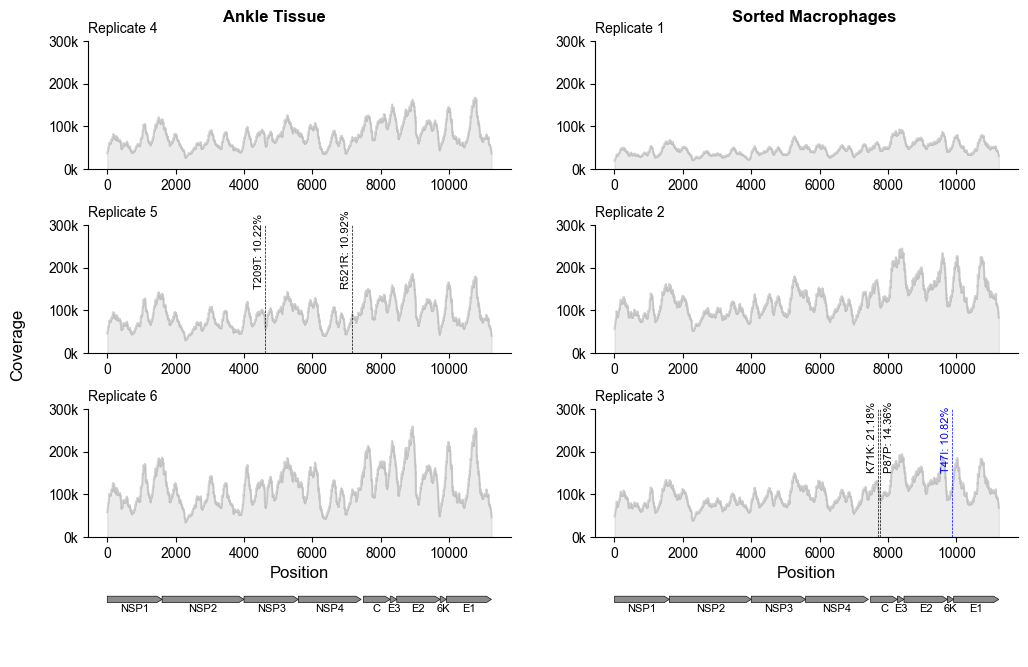

In [40]:
snvs = pd.read_csv('../results/animal_results/ankle_macrophages_snvs_10AF_cutoff.csv')

# Gene annotations
genes = [
  {"name": "NSP1", "start": 3, "end": 1605},
  {"name": "NSP2", "start": 1606, "end": 3999},
  {"name": "NSP3", "start": 4000, "end": 5589},
  {"name": "NSP4", "start": 5590, "end": 7425},
  {"name": "C", "start": 7491, "end": 8273},
  {"name": "E3", "start": 8274, "end": 8465},
  {"name": "E2", "start": 8466, "end": 9734},
  {"name": "6K", "start": 9735, "end": 9917},
  {"name": "E1", "start": 9918, "end": 11237},
]
sup_cov_af_color = 'grey'
syn_color = 'black'
nonsyn_color = 'blue'

sample_names = cov.columns
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(nrows=4, ncols=2, height_ratios=[0.6, 0.6, 0.6, 0.3], hspace=0.5)

axs = []
for i in range(6):
    row = i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    axs.append(ax)

for i, sample in enumerate(sample_names):
    ax = axs[i]
    ax.plot(cov.index, cov[sample], linestyle='-', color=sup_cov_af_color, alpha=0.3)
    ax.fill_between(cov.index, cov[sample], color=sup_cov_af_color, alpha=0.15)
    
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
    ax.set_ylim(0, 300000)
    ax.set_title(sample, fontsize=10, loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot SNV markers for this sample
    snvs_subset = snvs[snvs['SAMPLE_NAME'] == sample].sort_values('POSITION')

    flip = True
    for _, row in snvs_subset.iterrows():
        snv_pos = row['POSITION']
        label = row['LABEL']
        snv_color = syn_color if row['MUT_TYPE'] == 'synonymous' else nonsyn_color

        if snv_pos == 7751:
          ax.axvline(x=snv_pos, color=snv_color, linestyle='--', linewidth=0.5)
          text_offset = offset_copy(ax.transData, fig=fig, x=3, y=0, units='points')

          ax.text(
              snv_pos,
              ax.get_ylim()[1] * 0.5,
              label,
              fontsize=8,
              color=snv_color,
              ha='left',
              va='bottom',
              rotation=90,
              transform=text_offset
          )
        else:
            ax.axvline(x=snv_pos, color=snv_color, linestyle='--', linewidth=0.5)
            ax.text(
                snv_pos - 30,
                ax.get_ylim()[1] * 0.5,
                label,
                fontsize=8,
                color=snv_color,
                ha='right',
                va='bottom',
                rotation=90,
            )

for ax in axs[-2:]:
    ax.set_xlabel('Position', fontsize=12)

fig.text(0.06, 0.5, 'Coverage', va='center', rotation='vertical', fontsize=12)
fig.text(0.28, 0.90, plot_col_headers[0], ha='center', va='bottom', fontsize=12, weight='bold')
fig.text(0.73, 0.90, plot_col_headers[1], ha='center', va='bottom', fontsize=12, weight='bold')

for col in range(2):
    gene_ax = fig.add_subplot(gs[3, col])
    gene_ax.set_xlim(axs[0].get_xlim())
    gene_ax.set_ylim(0, 1)
    gene_ax.axis('off')

    arrow_y = 0.9 

    for gene in genes:
        gene_start = gene['start']
        gene_end = gene['end']
        gene_width = gene_end - gene_start
        head_length = max(gene_width * 0.01, 150)

        arrow = patches.FancyArrow(
            gene_start, arrow_y,
            gene_width, 0,
            width=0.1,
            length_includes_head=True,
            head_width=0.1,
            head_length=head_length,
            facecolor=sup_cov_af_color,
            edgecolor='black',
            linewidth=0.5,
            alpha=0.9
        )
        gene_ax.add_patch(arrow)

        gene_ax.text(
            (gene_start + gene_end) / 2,
            arrow_y - 0.07,
            gene['name'],
            ha='center',
            va='top',
            fontsize=8,
            color='black'
        )

fig.savefig('./figures/ankle_macrophages_cov-snv.pdf', bbox_inches='tight')
plt.show()
